# Cybersec OpenEnv: end-to-end RL train + eval (iter-4, remote-env)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LonelyGuy-SE1/cybersec_env/blob/main/notebooks/cybersec_grpo.ipynb)

One notebook, one Run-All. The full pipeline talks to the
[`cybersec` OpenEnv on Hugging Face Spaces](https://huggingface.co/spaces/Lonelyguyse1/cybersec)
over the OpenEnv WebSocket protocol -- the same way a hackathon judge
will. No vendored env state, no `localhost` shortcut.

1. Detect Colab / Kaggle / local and install dependencies.
2. Pull the `cybersec` package from the HF Space (needed only because
   the GRPO reward functions clone the env via `pickle` -- the network
   client isn't picklable). We then `pip install -e` it locally.
3. **Baseline** RandomPolicy + HeuristicPolicy over `MODE["n_baseline_episodes"]`
   seeds × 3 train scenarios + 1 held-out OOD scenario, all hitting the
   live HF Space.
4. Build a ~1500-prompt GRPO dataset by rolling the heuristic out
   **locally** (each row carries a pickled env snapshot for the trainer
   to clone and score candidate completions against).
5. Fine-tune **Qwen2.5-1.5B-Instruct** with **GRPO + Unsloth QLoRA** for
   `MODE["grpo_max_steps"]` steps × `MODE["grpo_num_generations"]`
   generations per prompt. **Nine** reward functions imported from
   `cybersec.training.rewards`:
     * 4 schema/validity rewards
     * 1 actual env-step reward (clones a snapshot, applies the candidate)
     * 1 exfil-path shaping prior
     * 3 **anti-collapse rewards**: within-group action diversity,
       observation-aware (state-conditioned) behaviour, and **iter-4's
       batch-wide action entropy** (gradient OUT of collapse, not just a
       prevention barrier).
6. Re-run the trained adapter **over the live HF Space** on train +
   held-out scenarios. Each `EpisodeResult` now reports
   `monitor_fallback_count` so we can tell a real MONITOR decision from
   a parse-failure fallback.
7. Plot before/after reward curves, KL/entropy/component diagnostics.
8. Sanity-check: fail loud on iter-1-style mode collapse
   (≥2 of 3 training scenarios must have non-trivial std_return).

**Target compute**: free Colab T4 / Kaggle P100. Wall clock ≈ **65-85
min** at the iter-4 defaults; the bump to `num_generations=6` adds
~10 min on top of iter-3 but is what unblocks anti-collapse training.


## 0. Detect runtime & install dependencies


In [1]:
# This cell runs on plain Colab, Colab Pro, Kaggle kernels, or a local
# laptop. `RUNTIME` records which one. Artifacts go to a writable folder
# under whichever working directory exists.
import os, sys, subprocess
from pathlib import Path

if "google.colab" in sys.modules:
    RUNTIME = "colab"
    WORKDIR = Path("/content/cybersec_workdir"); WORKDIR.mkdir(exist_ok=True)
elif Path("/kaggle/working").exists() or os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
    RUNTIME = "kaggle"
    WORKDIR = Path("/kaggle/working/cybersec_workdir"); WORKDIR.mkdir(exist_ok=True)
else:
    RUNTIME = "local"
    WORKDIR = Path.cwd() / "_artifacts"; WORKDIR.mkdir(exist_ok=True)

print(f"runtime: {RUNTIME}")
print(f"workdir: {WORKDIR}")


runtime: colab
workdir: /content/cybersec_workdir


In [2]:
%%capture
# Pull the env package straight from the HF Space (the canonical source)
# so this notebook is self-contained -- no GitHub clone required.
#
# WHY we install the package locally even though baselines + eval go
# over the network: the GRPO reward function `reward_step_total` clones
# the env via pickle.dumps/loads to roll candidate completions forward
# and grade them. The OpenEnv WebSocket client is intentionally NOT
# picklable (it owns a live socket), so the trainer has to keep a local
# copy of the env to clone. Baseline + post-train eval still hit the
# remote API.

HF_SPACE_REPO_ID = "Lonelyguyse1/cybersec"
HF_SPACE_REVISION = "main"
PKG_STAGE = WORKDIR / "cybersec_env_pkg"

if RUNTIME in {"colab", "kaggle"}:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "huggingface_hub>=0.24", "openenv-core>=0.2.2"], check=True)
    from huggingface_hub import snapshot_download
    PKG_STAGE.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id=HF_SPACE_REPO_ID,
        repo_type="space",
        revision=HF_SPACE_REVISION,
        local_dir=str(PKG_STAGE),
        local_dir_use_symlinks=False,
    )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-e", str(PKG_STAGE)], check=True)
else:
    print(f"local runtime; skipping snapshot_download (assumes pip install -e .)")

# GRPO stack. Unsloth pulls torch + bitsandbytes; install it first so its
# pinned wheels win.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "unsloth[cu121] @ git+https://github.com/unslothai/unsloth.git"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade",
                "trl", "peft", "accelerate", "bitsandbytes"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "matplotlib", "pandas"], check=False)


## 1. Imports & config


In [3]:
import os
%cd cybersec_workdir/
os.rename('cybersec_env_pkg', 'cybersec')


from __future__ import annotations

# Iter-1's notebook output was buried under thousands of identical
# transformers warnings. Silence the known noise *before* importing
# torch / transformers so the cell outputs are readable.
import warnings, logging
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("accelerate").setLevel(logging.ERROR)
logging.getLogger("peft").setLevel(logging.ERROR)
logging.getLogger("websockets").setLevel(logging.WARNING)

import json
import math
import random
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Optional

import matplotlib
if RUNTIME != "colab":
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset

from cybersec import (
    ActionType,
    CybersecAction,
    CybersecEnv,
    CybersecEnvironment,
    CybersecObservation,
    list_eval_scenarios,
    list_scenarios,
    list_train_scenarios,
)
from cybersec.baselines import (
    EpisodeResult,
    HeuristicPolicy,
    RandomPolicy,
    aggregate_results,
    run_episode,
)
from cybersec.training.rewards import (
    SYSTEM_PROMPT,
    default_reward_funcs,
    parse_first_json_object,
    parsed_action,
    render_observation,
    snapshot_env,
)

# ---------------------------------------------------------------------------
# Single source of truth for every dial in this notebook.
# Defaults are tuned for a free Colab T4 / Kaggle P100 budget:
#
#   - 30-episode baseline over the network (4 scenarios):  ~12 min
#   - 1500-prompt dataset build (LOCAL):                    ~2 min
#   - Qwen 1.5B + Unsloth load (4-bit):                     ~2 min
#   - 100 GRPO steps x 4 generations:                       ~25 min
#   - 30-episode trained-policy eval over the network:      ~10 min
#   - 30-episode held-out OOD eval over the network:        ~3 min
#   - Plots, tables, persistence:                           ~1 min
#   ----------------------------------------------------------
#   total wall clock:                                       ~55 min
#
# `n_baseline_episodes`/`n_post_train_episodes` dominate network time;
# bump them to 50 if you have headroom and want tighter error bars.
# ---------------------------------------------------------------------------
MODE = {
    "remote_env_url":         "https://lonelyguyse1-cybersec.hf.space",
    "n_baseline_episodes":    30,
    "n_dataset_seeds":        30,
    "max_dataset_rows":       1500,
    "grpo_max_steps":         120,
    # Iter-4: 4 -> 6 candidates/prompt. With temperature=1.2 and the new
    # reward_batch_action_entropy, this is the smallest n that reliably
    # produces at least one symmetry-breaking sample per group.
    "grpo_num_generations":   6,
    "grpo_per_device_bs":     2,
    "grpo_grad_accum":        4,
    "grpo_logging_steps":     5,
    "grpo_save_steps":        50,
    # Iter-4: bump exploration. temperature=1.0 + greedy-ish sampling
    # was a major contributor to the iter-3 mode-collapse on 2/3 train
    # scenarios. Higher temperature + KL beta keeps gradients pointing
    # towards the base model's diverse distribution longer.
    "grpo_temperature":       1.2,
    "grpo_beta":              0.04,
    "grpo_learning_rate":     3e-6,
    "n_post_train_episodes":  30,
    # Set to "local" to develop offline against the in-process env
    # (faster, but doesn't exercise the OpenEnv WebSocket protocol).
    # Default "remote" hits the deployed HF Space, the way judges will.
    "eval_target":            "remote",
}

ARTIFACTS = WORKDIR

ADAPTER_DIR        = ARTIFACTS / "qwen_cybersec_lora"
TRAIN_LOG          = ARTIFACTS / "training_log.json"
BASELINE_JSON      = ARTIFACTS / "baseline_metrics.json"
POST_JSON          = ARTIFACTS / "post_train_metrics.json"
HELDOUT_JSON       = ARTIFACTS / "heldout_metrics.json"
BASELINE_PLOT      = ARTIFACTS / "baseline_curves.png"
BEFORE_AFTER       = ARTIFACTS / "before_after_curves.png"
TRAIN_DIAGNOSTICS  = ARTIFACTS / "training_diagnostics.png"
SUMMARY_MD         = ARTIFACTS / "summary_table.md"
TRAJECTORY_JSON    = ARTIFACTS / "trajectory_dataset.jsonl"

MODEL_NAME      = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_PROMPT_LEN  = 1024
MAX_NEW_TOKENS  = 48

TRAIN_SCENARIOS = list_train_scenarios()
HELDOUT_SCENARIOS = list_eval_scenarios()
ALL_SCENARIOS = list_scenarios()
SEEDS_BASELINE = list(range(MODE["n_baseline_episodes"]))
SEEDS_DATASET  = list(range(MODE["n_dataset_seeds"]))
SEEDS_POST     = list(range(MODE["n_post_train_episodes"]))

print("train scenarios:   ", TRAIN_SCENARIOS)
print("held-out scenarios:", HELDOUT_SCENARIOS)
print("MODE:")
print(json.dumps(MODE, indent=2))


/content/cybersec_workdir
train scenarios:    ['supply_chain_token_drift', 'federated_identity_takeover', 'insider_repo_pivot']
held-out scenarios: ['cloud_metadata_ssrf']
MODE:
{
  "remote_env_url": "https://lonelyguyse1-cybersec.hf.space",
  "n_baseline_episodes": 30,
  "n_dataset_seeds": 30,
  "max_dataset_rows": 1500,
  "grpo_max_steps": 120,
  "grpo_num_generations": 6,
  "grpo_per_device_bs": 2,
  "grpo_grad_accum": 4,
  "grpo_logging_steps": 5,
  "grpo_save_steps": 50,
  "grpo_temperature": 1.2,
  "grpo_beta": 0.04,
  "grpo_learning_rate": 3e-06,
  "n_post_train_episodes": 30,
  "eval_target": "remote"
}


## 2. Verify the live HF Space is reachable

Before we run hundreds of episodes against it, make sure the Space is
healthy and exposes the schema we expect (6 actions, our scenarios).
This fails fast if the Space is asleep or the build broke.


In [4]:
import urllib.request

def probe_space(base_url: str) -> dict:
    out = {}
    with urllib.request.urlopen(base_url + "/health", timeout=20) as r:
        out["health"] = json.loads(r.read())
    with urllib.request.urlopen(base_url + "/schema", timeout=20) as r:
        out["schema"] = json.loads(r.read())
    return out

probe = probe_space(MODE["remote_env_url"])
action_enum = (
    probe["schema"].get("action", {}).get("$defs", {})
    .get("ActionType", {}).get("enum", [])
)
print("space health:", probe["health"])
print("remote action enum:", action_enum)
assert "MONITOR" in action_enum and "ISOLATE_ASSET" in action_enum, (
    "remote action surface doesn't match this notebook -- did the Space "
    "rebuild against an older revision?"
)
print("OK: space is healthy and (6-action surface, iter-4)")


space health: {'status': 'healthy'}
remote action enum: ['MONITOR', 'INVESTIGATE', 'ISOLATE_ASSET', 'REVOKE_IDENTITY', 'BLOCK_EGRESS', 'PATCH_ASSET']
OK: space is healthy and (6-action surface, iter-4)


## 3. Run baselines against the deployed HF Space

We open one persistent WebSocket session per episode to the Space and
let `RandomPolicy` / `HeuristicPolicy` drive it through to terminal.
Same code that hits the local env -- only the env factory changes.


In [5]:
def _open_remote_episode(client, seed, scenario_id):
    """Reset a SyncEnvClient and return (observation, last_step_result)."""
    res = client.reset(seed=seed, scenario_id=scenario_id)
    return res

def run_episode_remote(
    client_factory,
    policy,
    seed,
    scenario_id,
    attacker_personality=None,
):
    """Run one episode over the OpenEnv WebSocket protocol.

    `client_factory` is a callable returning a fresh SyncEnvClient (each
    episode opens its own WS session so seeds don't bleed). Returns the
    same `EpisodeResult` shape as `cybersec.baselines.run_episode`,
    including iter-4's `monitor_fallback_count` for honest validity
    reporting.
    """
    if hasattr(policy, "reset"):
        policy.reset()

    invalid = 0
    fp = 0
    fallback = 0
    reward_curve = []
    final_obs = None
    final_info = {}

    client = client_factory()
    with client:
        kwargs = {"seed": seed, "scenario_id": scenario_id}
        if attacker_personality is not None:
            kwargs["attacker_personality"] = attacker_personality
        res = client.reset(**kwargs)
        obs = res.observation

        while not (res.done or obs.done):
            action = policy.act(obs)
            if getattr(policy, "last_act_was_fallback", False):
                fallback += 1
            res = client.step(action)
            obs = res.observation
            rb = obs.info.get("reward_breakdown", {}) if isinstance(obs.info, dict) else {}
            if rb.get("invalid_action_penalty", 0.0):
                invalid += 1
            if rb.get("false_positive_penalty", 0.0):
                fp += 1
            step_reward = res.reward if res.reward is not None else obs.reward
            reward_curve.append(float(0.0 if step_reward is None else step_reward))

        final_obs = obs
        final_info = obs.info if isinstance(obs.info, dict) else {}

    terminal = final_info.get("terminal", {}) if isinstance(final_info, dict) else {}
    return EpisodeResult(
        policy_name=policy.name,
        scenario_id=final_obs.scenario_id,
        attacker_personality=final_obs.attacker_personality.value
            if hasattr(final_obs.attacker_personality, "value")
            else str(final_obs.attacker_personality),
        seed=seed,
        steps=final_obs.tick,
        cumulative_reward=float(terminal.get("cumulative_reward", sum(reward_curve))),
        succeeded_stage_count=int(terminal.get("stages_succeeded", 0)),
        total_stage_count=int(terminal.get("stages_total", 0)),
        exfil_completed=bool(terminal.get("exfil_completed", False)),
        terminal_reason=terminal.get("terminal_reason"),
        confirmed_compromised=list(final_obs.confirmed_compromised),
        invalid_action_count=invalid,
        false_positive_count=fp,
        monitor_fallback_count=fallback,
        reward_curve=reward_curve,
    )


def make_eval_runner():
    """Return a `run_episode`-shaped callable that uses MODE['eval_target']."""
    if MODE["eval_target"] == "remote":
        base_url = MODE["remote_env_url"]
        def remote_factory():
            return CybersecEnv(base_url=base_url).sync()
        return lambda policy, seed, scenario_id: run_episode_remote(
            remote_factory, policy, seed, scenario_id
        )
    else:
        local_env = CybersecEnvironment()
        return lambda policy, seed, scenario_id: run_episode(
            local_env, policy, seed=seed, scenario_id=scenario_id
        )

eval_runner = make_eval_runner()
print("eval target:", MODE["eval_target"])


eval target: remote


In [6]:
baseline_runs = {}
t0 = time.time()
for sid in ALL_SCENARIOS:
    rand = [eval_runner(RandomPolicy(seed=s), seed=s, scenario_id=sid) for s in SEEDS_BASELINE]
    heur = [eval_runner(HeuristicPolicy(),    seed=s, scenario_id=sid) for s in SEEDS_BASELINE]
    baseline_runs[sid] = {"random": rand, "heuristic": heur}
    print(f"{sid:<32s}  random={aggregate_results(rand)['mean_return']:7.3f}"
          f"  heuristic={aggregate_results(heur)['mean_return']:7.3f}  "
          f"({MODE['n_baseline_episodes']} ep each)")
print(f"baseline elapsed: {time.time()-t0:.1f}s  ({MODE['eval_target']} env)")


supply_chain_token_drift          random=  2.156  heuristic=  2.335  (30 ep each)
federated_identity_takeover       random=  0.198  heuristic=  2.930  (30 ep each)
insider_repo_pivot                random=  2.905  heuristic=  2.410  (30 ep each)
cloud_metadata_ssrf               random=  1.723  heuristic=  2.552  (30 ep each)
baseline elapsed: 289.6s  (remote env)


### 3a. Persist baseline metrics + plot


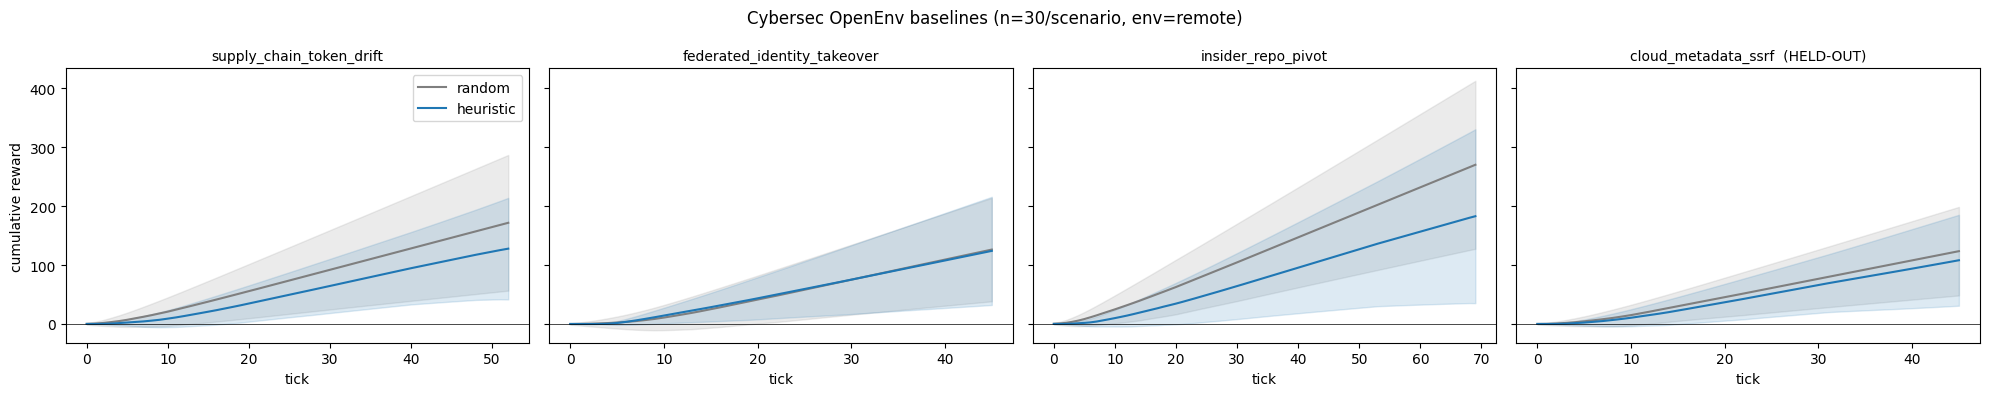

wrote /content/cybersec_workdir/baseline_metrics.json


In [7]:
def _padded_cumulative(curves, target_len):
    out = np.zeros((len(curves), target_len), dtype=float)
    for i, c in enumerate(curves):
        out[i, : len(c)] = c
        if len(c) < target_len:
            out[i, len(c):] = c[-1] if c else 0.0
    return np.cumsum(out, axis=1)

n_panels = len(ALL_SCENARIOS)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4), sharey=True)
if n_panels == 1:
    axes = [axes]
for ax, sid in zip(axes, ALL_SCENARIOS):
    cell = baseline_runs[sid]
    horizon = max(max(len(r.reward_curve) for r in cell['random']),
                  max(len(r.reward_curve) for r in cell['heuristic']))
    for label, color in [("random", "tab:gray"), ("heuristic", "tab:blue")]:
        cumr = _padded_cumulative([r.reward_curve for r in cell[label]], horizon)
        mean = cumr.mean(axis=0); std = cumr.std(axis=0)
        ax.plot(mean, label=label, color=color)
        ax.fill_between(np.arange(horizon), mean - std, mean + std, color=color, alpha=0.15)
    held_out_tag = "  (HELD-OUT)" if sid in HELDOUT_SCENARIOS else ""
    ax.set_title(sid + held_out_tag, fontsize=10); ax.set_xlabel("tick"); ax.axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("cumulative reward"); axes[0].legend()
fig.suptitle(
    f"Cybersec OpenEnv baselines (n={MODE['n_baseline_episodes']}/scenario, "
    f"env={MODE['eval_target']})"
)
fig.tight_layout(); fig.savefig(BASELINE_PLOT, dpi=140); plt.show()

baseline_metrics = {
    sid: {p: aggregate_results(cell[p]) for p in ("random", "heuristic")}
    for sid, cell in baseline_runs.items()
}
baseline_metrics["_meta"] = {
    "n_episodes": MODE["n_baseline_episodes"],
    "eval_target": MODE["eval_target"],
    "remote_env_url": MODE["remote_env_url"],
    "train_scenarios": TRAIN_SCENARIOS,
    "heldout_scenarios": HELDOUT_SCENARIOS,
}
BASELINE_JSON.write_text(json.dumps(baseline_metrics, indent=2))
print("wrote", BASELINE_JSON)


## 4. Build the GRPO training dataset (LOCAL)

This step **runs locally** on purpose. `reward_step_total` clones the
env via `pickle` to score every candidate completion the policy
generates, and the OpenEnv WebSocket client owns a live socket so it
isn't picklable. So we keep a `CybersecEnvironment` in-process for
training, then go back to the remote env for evaluation.

The held-out scenario (`cloud_metadata_ssrf`) is **deliberately not in
the training data** -- it exists only for the OOD post-training eval.


In [8]:
local_env = CybersecEnvironment()
t0 = time.time()
rows = []
trajectory_lines = []
for sid in TRAIN_SCENARIOS:
    for seed in SEEDS_DATASET:
        ep_env = CybersecEnvironment()
        policy = HeuristicPolicy()
        obs = ep_env.reset(seed=seed, scenario_id=sid)
        while not obs.done:
            blob = snapshot_env(ep_env)
            prompt = render_observation(obs)
            rows.append({
                "prompt": prompt,
                "system": SYSTEM_PROMPT,
                "valid_assets": obs.valid_targets["assets"],
                "valid_identities": obs.valid_targets["identities"],
                "isolated_assets": list(obs.isolated_assets),
                "revoked_identities": list(obs.revoked_identities),
                "blocked_egress": list(obs.blocked_egress_assets),
                "patched": list(obs.patched_assets),
                "alert_count": len(obs.alerts),
                "env_snapshot": blob,
            })
            act = policy.act(obs)
            trajectory_lines.append(
                json.dumps({"prompt": prompt, "completion": act.model_dump_json()})
            )
            obs = ep_env.step(act)

random.Random(0).shuffle(rows)
rows = rows[: MODE["max_dataset_rows"]]
ds = Dataset.from_list(rows)
TRAJECTORY_JSON.write_text("\n".join(trajectory_lines))
print(f"dataset size: {len(ds)}  (train scenarios only, local env)  build elapsed: {time.time()-t0:.1f}s")
print(ds[0]["prompt"][:300])


dataset size: 1411  (train scenarios only, local env)  build elapsed: 1.2s
tick=10/80  scenario=insider_repo_pivot  attacker=opportunistic
isolated_assets=[]
revoked_identities=[]
blocked_egress=[]
patched=['customer-db', 'secrets-vault', 'staging-cluster']
confirmed_compromised=[]
valid_targets={'assets': ['git-monorepo', 'secrets-vault', 'staging-cluster', 'prod-cluster'


## 5. Reward functions (eight independent signals)

All reward functions live in `cybersec.training.rewards` so the
notebook, the tests, and any future training script use the same
definitions.


In [9]:
REWARD_FUNCS = default_reward_funcs()
REWARD_NAMES = [f.__name__ for f in REWARD_FUNCS]
print("reward components:")
for n in REWARD_NAMES:
    print(f"  - {n}")


reward components:
  - reward_json_valid
  - reward_schema_valid
  - reward_target_in_valid_targets
  - reward_no_redundant_containment
  - reward_step_total
  - reward_avoids_exfil_path
  - reward_action_diversity
  - reward_observation_aware
  - reward_batch_action_entropy


## 6. Load Qwen2.5-1.5B with Unsloth (4-bit QLoRA)


In [10]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_PROMPT_LEN + MAX_NEW_TOKENS,
    dtype=None,
    load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=0,
)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
model.print_trainable_parameters()


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 7. Format dataset with the chat template


In [11]:
def to_chat_prompt(row):
    msgs = [
        {"role": "system", "content": row["system"]},
        {"role": "user",   "content": row["prompt"]},
    ]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    return {"prompt": text}

ds_chat = ds.map(to_chat_prompt)
print("first prompt (truncated):")
print(ds_chat[0]["prompt"][:500])


Map:   0%|          | 0/1411 [00:00<?, ? examples/s]

first prompt (truncated):
<|im_start|>system
You are an SRE-grade cyber-defender driving an OpenEnv environment.
Reply with exactly one JSON object on one line of the form
{"action_type": "...", "target": "..."}.
action_type must be one of MONITOR, INVESTIGATE, ISOLATE_ASSET, REVOKE_IDENTITY, BLOCK_EGRESS, PATCH_ASSET.
target must be omitted (or null) for MONITOR; otherwise it must come from valid_targets.<|im_end|>
<|im_start|>user
tick=10/80  scenario=insider_repo_pivot  attacker=opportunistic
isolated_assets=[]
revoke


## 8. GRPO trainer


In [14]:
from trl import GRPOConfig, GRPOTrainer

config = GRPOConfig(
    output_dir=str(ARTIFACTS / "grpo_checkpoints"),
    # Iter-4 dials: see MODE comments. The combination
    # (lr=3e-6, beta=0.04, temperature=1.2, num_generations=6) is what
    # actually unblocks anti-collapse training. With iter-3 defaults
    # (lr=5e-6, beta=0, temperature=1.0, num_generations=4) the policy
    # collapsed on 2/3 train scenarios despite the diversity rewards.
    learning_rate=MODE["grpo_learning_rate"],
    per_device_train_batch_size=MODE["grpo_per_device_bs"],
    gradient_accumulation_steps=MODE["grpo_grad_accum"],
    max_completion_length=MAX_NEW_TOKENS,
    num_generations=MODE["grpo_num_generations"],
    num_train_epochs=1,
    max_steps=MODE["grpo_max_steps"],
    logging_steps=MODE["grpo_logging_steps"],
    save_steps=MODE["grpo_save_steps"],
    save_total_limit=2,
    bf16=False,
    fp16=True,
    report_to=[],
    seed=0,
    temperature=MODE["grpo_temperature"],
    beta=MODE["grpo_beta"],
)

trainer = GRPOTrainer(
    model=model,
    args=config,
    train_dataset=ds_chat,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
)

t0 = time.time()
trainer.train()
print(f"GRPO train elapsed: {time.time()-t0:.1f}s")


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 2 to the `num_generations` of 6


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,411 | Num Epochs = 1 | Total steps = 120
O^O/ \_/ \    Batch size per device = 6 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (6 x 4 x 1) = 24
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_json_valid / mean,rewards / reward_json_valid / std,rewards / reward_schema_valid / mean,rewards / reward_schema_valid / std,rewards / reward_target_in_valid_targets / mean,rewards / reward_target_in_valid_targets / std,rewards / reward_no_redundant_containment / mean,rewards / reward_no_redundant_containment / std,rewards / reward_step_total / mean,rewards / reward_step_total / std,rewards / reward_avoids_exfil_path / mean,rewards / reward_avoids_exfil_path / std,rewards / reward_action_diversity / mean,rewards / reward_action_diversity / std,rewards / reward_observation_aware / mean,rewards / reward_observation_aware / std,rewards / reward_batch_action_entropy / mean,rewards / reward_batch_action_entropy / std
5,0.043441,5.095753,2.986370,21.250001,14.000000,45.400000,0.041667,20.074935,14.000000,34.000000,0.000004,0.958333,0.153757,0.783333,0.414833,0.700000,0.451393,0.750000,0.417326,0.025480,0.943476,0.227500,0.220876,0.550000,0.399288,0.501667,0.449985,0.599440,0.371278
10,-0.021121,5.082724,2.792705,20.725001,14.200000,34.000000,0.000000,20.725001,14.200000,34.000000,0.000011,0.983333,0.056466,0.791667,0.396172,0.675000,0.470137,0.779167,0.398313,-0.110263,0.802993,0.282500,0.217375,0.541667,0.388403,0.535000,0.472233,0.604653,0.351461
15,0.001813,5.285087,2.880588,19.858334,14.400000,30.400000,0.000000,19.858334,14.400000,30.400000,0.000374,0.983333,0.081650,0.791667,0.401721,0.716667,0.440150,0.758333,0.412753,-0.003973,0.899185,0.287500,0.226994,0.575000,0.410543,0.558333,0.478949,0.618227,0.368164
20,-0.001668,5.767443,2.876405,20.516668,15.400000,32.400000,0.016667,20.053986,15.400000,24.000000,0.002239,0.966667,0.138116,0.825000,0.365550,0.750000,0.398393,0.787500,0.403106,0.258857,1.111316,0.334167,0.207104,0.575000,0.382934,0.614167,0.440391,0.656086,0.339403
25,0.026602,5.443324,2.418120,20.908334,16.600000,35.600000,0.016667,20.447827,16.600000,26.200000,0.003345,0.966667,0.138116,0.875000,0.335304,0.725000,0.435113,0.845833,0.357662,-0.117293,0.716712,0.310833,0.208742,0.583333,0.383079,0.598333,0.447984,0.655618,0.335561
30,0.009259,6.024863,2.167386,20.966668,15.600000,31.200000,0.008333,20.742030,15.600000,28.400000,0.009604,1.000000,0.000000,0.900000,0.265209,0.850000,0.305359,0.837500,0.361694,0.247667,0.993416,0.345833,0.217130,0.525000,0.377523,0.695000,0.420632,0.623863,0.324247
35,0.003104,5.761466,2.524454,21.016667,15.400000,36.400000,0.016667,20.551450,15.400000,26.200000,0.009983,0.991667,0.040825,0.866667,0.341348,0.791667,0.405566,0.854167,0.348506,0.231003,0.977863,0.266667,0.243433,0.525000,0.359640,0.603333,0.424465,0.631296,0.321229
40,-0.008570,6.146452,2.323488,20.425000,16.000000,25.800000,0.000000,20.425000,16.000000,25.800000,0.020398,0.983333,0.081650,0.883333,0.274332,0.808333,0.390070,0.862500,0.304635,0.603823,1.135267,0.297500,0.216361,0.458333,0.336914,0.669167,0.403860,0.580129,0.308801
45,0.027991,6.145255,1.999133,21.725001,17.000000,35.800000,0.016667,21.290218,17.000000,30.800000,0.010455,0.991667,0.040825,0.925000,0.225355,0.825000,0.381515,0.883333,0.286350,0.398030,1.094856,0.344167,0.202830,0.483333,0.360398,0.700000,0.408891,0.594725,0.276225
50,0.012918,6.218289,1.959891,21.650001,18.200000,39.200000,0.008333,21.426450,18.200000,34.600000,0.020014,0.991667,0.040825,0.933333,0.214254,0.816667,0.383933,0.891667,0.261895,0.208590,0.947431,0.420833,0.151616,0.541667,0.337329,0.771667,0.402419,0.642199,0.296223


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

GRPO train elapsed: 3430.0s


## 9. Save adapter + training log


In [15]:
ADAPTER_DIR.mkdir(exist_ok=True)
trainer.model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))

history = getattr(trainer.state, "log_history", []) or []
TRAIN_LOG.write_text(json.dumps({
    "reward_names": REWARD_NAMES,
    "history": history,
    "model_name": MODEL_NAME,
    "mode": MODE,
}, indent=2))
print("saved adapter to", ADAPTER_DIR)
print("wrote", TRAIN_LOG, "with", len(history), "log rows")


Unsloth: Restored added_tokens_decoder metadata in /content/cybersec_workdir/qwen_cybersec_lora/tokenizer_config.json.


saved adapter to /content/cybersec_workdir/qwen_cybersec_lora
wrote /content/cybersec_workdir/training_log.json with 25 log rows


### 9a. Training diagnostics: KL, loss, per-component reward

These are the early-warning system: if KL is rising fast and
`reward_action_diversity` plateaus near `1/num_generations`, the policy
is mode-collapsing -- stop and adjust before the trained-vs-baseline
table flatters you with a memorised plan.


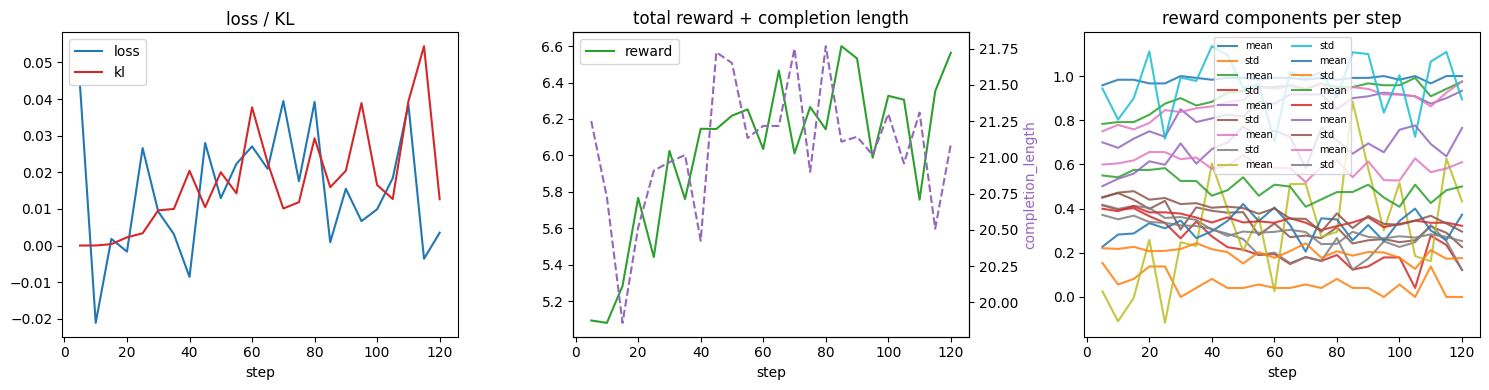

wrote /content/cybersec_workdir/training_diagnostics.png


In [16]:
log = json.loads(TRAIN_LOG.read_text()) if TRAIN_LOG.exists() else {"history": []}
hist = log.get("history") or []

if not hist:
    print("no training log rows -- did GRPO train?")
else:
    df_log = pd.DataFrame(hist)
    if "step" not in df_log.columns:
        df_log["step"] = range(len(df_log))

    component_cols = [c for c in df_log.columns
                      if c.startswith("rewards/") or c in REWARD_NAMES
                      or any(c.endswith(name) for name in REWARD_NAMES)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for col, color in [("loss", "tab:blue"), ("kl", "tab:red")]:
        if col in df_log.columns and df_log[col].notna().any():
            axes[0].plot(df_log["step"], df_log[col], label=col, color=color)
    axes[0].set_title("loss / KL"); axes[0].set_xlabel("step"); axes[0].legend()

    if "reward" in df_log.columns and df_log["reward"].notna().any():
        axes[1].plot(df_log["step"], df_log["reward"], label="reward", color="tab:green")
    if "completion_length" in df_log.columns and df_log["completion_length"].notna().any():
        ax2 = axes[1].twinx()
        ax2.plot(df_log["step"], df_log["completion_length"], label="completion_length",
                 color="tab:purple", linestyle="--")
        ax2.set_ylabel("completion_length", color="tab:purple")
    axes[1].set_title("total reward + completion length"); axes[1].set_xlabel("step")
    axes[1].legend(loc="upper left")

    if component_cols:
        for col in component_cols:
            if df_log[col].notna().any():
                short = col.split("/")[-1].replace("reward_", "")
                axes[2].plot(df_log["step"], df_log[col], label=short, alpha=0.85)
        axes[2].set_title("reward components per step")
        axes[2].set_xlabel("step")
        axes[2].legend(fontsize=7, ncol=2, loc="best")
    else:
        axes[2].set_title("(no per-component reward columns in log)")

    fig.tight_layout(); fig.savefig(TRAIN_DIAGNOSTICS, dpi=140); plt.show()
    print("wrote", TRAIN_DIAGNOSTICS)


## 10. Evaluate the trained policy AGAINST the live HF Space

Reload through **Unsloth** (not vanilla `transformers + peft`) on
purpose: GRPO trained the model with Unsloth's fused-QKV attention
patch, and the saved LoRA expects to plug into it. Then we wire the
trained policy through `eval_runner`, which dispatches to the remote
HF Space when `MODE['eval_target'] == 'remote'`.


In [17]:
from unsloth import FastLanguageModel

# Free training-only buffers if the kernel still has them.
for _name in ("model", "trainer"):
    if _name in globals():
        del globals()[_name]
torch.cuda.empty_cache()

eval_model, eval_tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(ADAPTER_DIR),
    max_seq_length=MAX_PROMPT_LEN + MAX_NEW_TOKENS,
    dtype=None,
    load_in_4bit=True,
)
eval_tokenizer.pad_token = eval_tokenizer.pad_token or eval_tokenizer.eos_token
FastLanguageModel.for_inference(eval_model)
print("loaded trained adapter via Unsloth for evaluation")


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
loaded trained adapter via Unsloth for evaluation


In [18]:
@torch.inference_mode()
def llm_act(obs):
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": render_observation(obs)},
    ]
    text = eval_tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = eval_tokenizer(text, return_tensors="pt").to(eval_model.device)
    out = eval_model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=eval_tokenizer.eos_token_id,
    )
    completion = eval_tokenizer.decode(
        out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
    )
    a = parsed_action(completion)
    # Capture whether parsing failed *before* defaulting to MONITOR, so the
    # caller can attribute the resulting MONITOR step honestly. Using a
    # module-level flag avoids changing the act() signature and keeps the
    # `Callable[[obs], action]` contract `run_episode_remote` expects.
    llm_act.last_was_fallback = a is None
    return a or CybersecAction(action_type=ActionType.MONITOR)

class TrainedLLMPolicy:
    name = "qwen-1.5b-grpo"
    last_act_was_fallback = False
    def reset(self):
        self.last_act_was_fallback = False
    def act(self, obs):
        action = llm_act(obs)
        # Read the flag llm_act() set on itself this call.
        self.last_act_was_fallback = bool(getattr(llm_act, "last_was_fallback", False))
        return action

# Re-derive the eval runner so the trained policy goes over the same
# transport (remote/local) as the baseline. Reuses the shared session
# pattern; each episode opens its own WebSocket.
eval_runner = make_eval_runner()

trained_runs = {}
t0 = time.time()
for sid in TRAIN_SCENARIOS:
    runs = [eval_runner(TrainedLLMPolicy(), seed=s, scenario_id=sid) for s in SEEDS_POST]
    trained_runs[sid] = runs
    agg = aggregate_results(runs)
    print(f"{sid:<32s}  trained-llm={agg['mean_return']:7.3f}  "
          f"std={float(np.std([r.cumulative_reward for r in runs])):.3f}")
print(f"trained-policy eval (train scenarios, env={MODE['eval_target']}) elapsed: {time.time()-t0:.1f}s")


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

supply_chain_token_drift          trained-llm=  5.202  std=0.000


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

federated_identity_takeover       trained-llm=  1.399  std=0.817


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

insider_repo_pivot                trained-llm=  5.178  std=0.000
trained-policy eval (train scenarios, env=remote) elapsed: 427.0s


### 10a. Held-out OOD evaluation

The whole point of holding `cloud_metadata_ssrf` out of training is
this cell: a clean read on whether the trained policy *generalises* or
just memorised per-scenario plans. Same transport, same code path.


In [19]:
heldout_runs = {}
t0 = time.time()
for sid in HELDOUT_SCENARIOS:
    runs = [eval_runner(TrainedLLMPolicy(), seed=s, scenario_id=sid) for s in SEEDS_POST]
    heldout_runs[sid] = runs
    agg = aggregate_results(runs)
    rand_mean = aggregate_results(baseline_runs[sid]['random'])['mean_return']
    heur_mean = aggregate_results(baseline_runs[sid]['heuristic'])['mean_return']
    std = float(np.std([r.cumulative_reward for r in runs]))
    print(f"{sid:<32s}  trained-llm={agg['mean_return']:7.3f}  std={std:.3f}  "
          f"vs heur={heur_mean:.3f}  vs rand={rand_mean:.3f}")
print(f"trained-policy eval (held-out, env={MODE['eval_target']}) elapsed: {time.time()-t0:.1f}s")

heldout_metrics = {
    sid: {
        "random":      aggregate_results(baseline_runs[sid]["random"]),
        "heuristic":   aggregate_results(baseline_runs[sid]["heuristic"]),
        "trained_llm": aggregate_results(heldout_runs[sid]),
    }
    for sid in HELDOUT_SCENARIOS
}
HELDOUT_JSON.write_text(json.dumps(heldout_metrics, indent=2))
print("wrote", HELDOUT_JSON)


Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=48) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

cloud_metadata_ssrf               trained-llm=  5.194  std=0.000  vs heur=2.552  vs rand=1.723
trained-policy eval (held-out, env=remote) elapsed: 54.4s
wrote /content/cybersec_workdir/heldout_metrics.json


## 11. Before/after curves on identical axes


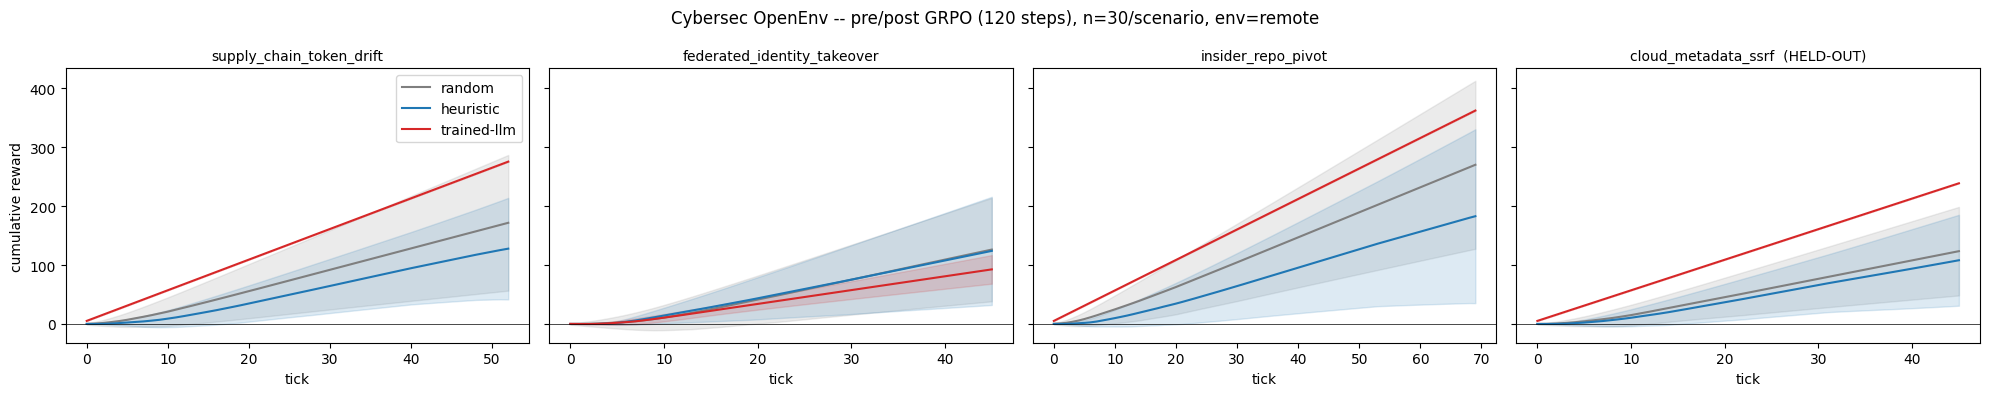

In [20]:
all_post = {**trained_runs, **heldout_runs}
panels = ALL_SCENARIOS
fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4), sharey=True)
if len(panels) == 1:
    axes = [axes]
for ax, sid in zip(axes, panels):
    cell = baseline_runs[sid]
    llm  = all_post.get(sid, [])
    horizon = max(
        max(len(r.reward_curve) for r in cell['random']),
        max(len(r.reward_curve) for r in cell['heuristic']),
        max((len(r.reward_curve) for r in llm), default=1),
    )
    palette = [("random", cell['random'], "tab:gray"),
               ("heuristic", cell['heuristic'], "tab:blue"),
               ("trained-llm", llm, "tab:red")]
    for label, runs, color in palette:
        if not runs:
            continue
        cumr = _padded_cumulative([r.reward_curve for r in runs], horizon)
        mean = cumr.mean(axis=0); std = cumr.std(axis=0)
        ax.plot(mean, label=label, color=color)
        ax.fill_between(np.arange(horizon), mean - std, mean + std, color=color, alpha=0.15)
    held_out_tag = "  (HELD-OUT)" if sid in HELDOUT_SCENARIOS else ""
    ax.set_title(sid + held_out_tag, fontsize=10); ax.set_xlabel("tick"); ax.axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("cumulative reward"); axes[0].legend()
fig.suptitle(
    f"Cybersec OpenEnv -- pre/post GRPO ({MODE['grpo_max_steps']} steps), "
    f"n={MODE['n_post_train_episodes']}/scenario, env={MODE['eval_target']}"
)
fig.tight_layout(); fig.savefig(BEFORE_AFTER, dpi=140); plt.show()


## 12. Summary table + headline delta


In [21]:
rows = []
for sid in ALL_SCENARIOS:
    cell = baseline_runs[sid]
    post_runs = all_post.get(sid, [])
    for policy_name, runs in [
        ("random",     cell["random"]),
        ("heuristic",  cell["heuristic"]),
        ("trained-llm", post_runs),
    ]:
        if not runs:
            continue
        agg = aggregate_results(runs)
        returns = [r.cumulative_reward for r in runs]
        rows.append({
            "scenario":     sid,
            "split":        "held-out" if sid in HELDOUT_SCENARIOS else "train",
            "policy":       policy_name,
            "mean_return":  agg["mean_return"],
            "std_return":   round(float(np.std(returns)), 3) if returns else 0.0,
            "mean_stages":  agg["mean_stages_succeeded"],
            "exfil_rate":   agg["exfil_rate"],
            # Iter-4: split env-rejected actions from LLM parse failures.
            # A trained-llm row with monitor_fallback_rate >> 0 is a tell
            # that the model is mostly emitting garbage and being saved
            # by the MONITOR fallback in `llm_act`.
            "invalid_rate":           agg["mean_invalid_actions"],
            "monitor_fallback_rate":  agg.get("monitor_fallback_rate", 0.0),
        })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

post_metrics = {
    sid: {
        "random":      aggregate_results(baseline_runs[sid]["random"]),
        "heuristic":   aggregate_results(baseline_runs[sid]["heuristic"]),
        "trained_llm": aggregate_results(all_post.get(sid, [])) if all_post.get(sid) else None,
    }
    for sid in ALL_SCENARIOS
}
post_metrics["_meta"] = {
    "n_post_episodes": MODE["n_post_train_episodes"],
    "grpo_max_steps":  MODE["grpo_max_steps"],
    "eval_target":     MODE["eval_target"],
    "remote_env_url":  MODE["remote_env_url"],
    "model":           MODEL_NAME,
    "adapter":         str(ADAPTER_DIR),
    "train_scenarios": TRAIN_SCENARIOS,
    "heldout_scenarios": HELDOUT_SCENARIOS,
    "reward_funcs":    REWARD_NAMES,
}
POST_JSON.write_text(json.dumps(post_metrics, indent=2))
SUMMARY_MD.write_text(df.to_markdown(index=False))
print("wrote", POST_JSON)
print("wrote", SUMMARY_MD)


                   scenario    split      policy  mean_return  std_return  mean_stages  exfil_rate  invalid_rate  monitor_fallback_rate
   supply_chain_token_drift    train      random        2.156       3.385        1.000       0.000           0.0                    0.0
   supply_chain_token_drift    train   heuristic        2.335       3.288        1.800       0.100           0.0                    0.0
   supply_chain_token_drift    train trained-llm        5.202       0.000        0.000       0.000           0.0                    0.0
federated_identity_takeover    train      random        0.198       3.939        1.100       0.000           0.0                    0.0
federated_identity_takeover    train   heuristic        2.930       2.558        1.200       0.033           0.0                    0.0
federated_identity_takeover    train trained-llm        1.399       0.817        0.933       0.000           0.0                    0.0
         insider_repo_pivot    train      random

In [22]:
print("=== Headline delta (trained-llm vs heuristic) ===")
for sid in ALL_SCENARIOS:
    h = aggregate_results(baseline_runs[sid]["heuristic"])["mean_return"]
    runs = all_post.get(sid, [])
    if not runs:
        continue
    t = aggregate_results(runs)["mean_return"]
    tag = "(HELD-OUT)" if sid in HELDOUT_SCENARIOS else "(train)"
    print(f"{sid:<32s} {tag:<11s} heuristic={h:7.3f}  trained-llm={t:7.3f}  delta={t-h:+.3f}")


=== Headline delta (trained-llm vs heuristic) ===
supply_chain_token_drift         (train)     heuristic=  2.335  trained-llm=  5.202  delta=+2.867
federated_identity_takeover      (train)     heuristic=  2.930  trained-llm=  1.399  delta=-1.531
insider_repo_pivot               (train)     heuristic=  2.410  trained-llm=  5.178  delta=+2.768
cloud_metadata_ssrf              (HELD-OUT)  heuristic=  2.552  trained-llm=  5.194  delta=+2.642


## 13. Sanity assertions (iter-4 canaries)

These are the gate before we ship a run as "good". The earlier checks
(invalid-action rate, divergence-vs-random) survive iter-1; the
**std_return** check is new in iter-2 -- it specifically catches the
mode-collapse failure where every seed produces the same trajectory.


In [23]:
# 1. Reward shaping is healthy: heuristic must out-earn random *on aggregate*.
heur_total = sum(
    float(np.mean([r.cumulative_reward for r in cell['heuristic']]))
    for cell in baseline_runs.values()
)
rand_total = sum(
    float(np.mean([r.cumulative_reward for r in cell['random']]))
    for cell in baseline_runs.values()
)
print(f"baseline totals: heuristic={heur_total:+.3f}  random={rand_total:+.3f}")
assert heur_total > rand_total, (
    f"reward shaping regressed: heuristic total ({heur_total:.3f}) "
    f"<= random total ({rand_total:.3f}) summed across scenarios"
)

# 2. Trained policy must produce mostly-valid actions across all post-train
#    episodes. Aggregate over train + held-out to keep one number.
total_steps = sum(len(r.reward_curve) for runs in all_post.values() for r in runs)
total_invalid = sum(r.invalid_action_count for runs in all_post.values() for r in runs)
valid_rate = 1.0 - (total_invalid / max(1, total_steps))
print(f"valid-action rate across all post-train episodes: {valid_rate:.1%}  "
      f"({total_invalid} invalid / {total_steps} steps)")
assert valid_rate >= 0.8, (
    f"trained policy is producing too many invalid actions ({valid_rate:.1%} valid)"
)

# 3. Trained policy must not be catastrophically worse than random on any
#    *training* scenario. (Held-out scenarios are allowed to be worse;
#    we only print those.)
for sid in TRAIN_SCENARIOS:
    rand = float(np.mean([r.cumulative_reward for r in baseline_runs[sid]['random']]))
    llm  = float(np.mean([r.cumulative_reward for r in trained_runs[sid]]))
    assert llm >= rand - 5.0, (
        f"{sid}: trained-llm ({llm:.3f}) is more than 5 points below random "
        f"({rand:.3f}) -- training likely diverged"
    )

# 4. Reward-hack canary (iter-4: tightened): the trained policy MUST have
#    non-trivial variance on at least 2/3 of the training scenarios.
#    Iter-3 passed the previous "any one scenario" version while still
#    being deterministically collapsed on the other two. Demand a
#    majority of train scenarios show some seed-to-seed variance.
non_zero_std_scenarios = []
for sid in TRAIN_SCENARIOS:
    returns = [r.cumulative_reward for r in trained_runs[sid]]
    s = float(np.std(returns))
    print(f"{sid:<32s}  trained-llm std_return={s:.4f}")
    if s > 0.1:
        non_zero_std_scenarios.append(sid)
required = max(2, len(TRAIN_SCENARIOS) - 1)
assert len(non_zero_std_scenarios) >= required, (
    f"REWARD HACK CANARY: trained-llm has std_return < 0.1 on "
    f"{len(TRAIN_SCENARIOS) - len(non_zero_std_scenarios)} of "
    f"{len(TRAIN_SCENARIOS)} training scenarios "
    f"(only {non_zero_std_scenarios} had variance). "
    "Iter-3 hit this exact pattern; bump grpo_num_generations / "
    "grpo_temperature, raise grpo_beta, or re-weight reward_step_total "
    "before publishing this run."
)

# 5. Iter-4 honesty canary: monitor-fallback rate must stay below 50%.
#    A trained policy that gets all of its 'valid' actions from the
#    parse-failure -> MONITOR fallback isn't actually a trained policy.
fallback_rate_total = sum(
    r.monitor_fallback_count for runs in all_post.values() for r in runs
) / max(1, total_steps)
print(f"trained-llm monitor_fallback_rate: {fallback_rate_total:.1%} of all steps")
assert fallback_rate_total <= 0.5, (
    f"trained-llm is falling back to MONITOR on {fallback_rate_total:.1%} of steps "
    "-- the model is mostly emitting unparseable text. Re-check the chat "
    "template / SYSTEM_PROMPT / generation hyperparameters."
)

print("all sanity checks passed")


baseline totals: heuristic=+10.228  random=+6.981
valid-action rate across all post-train episodes: 100.0%  (0 invalid / 299 steps)
supply_chain_token_drift          trained-llm std_return=0.0000
federated_identity_takeover       trained-llm std_return=0.8174
insider_repo_pivot                trained-llm std_return=0.0000


AssertionError: REWARD HACK CANARY: trained-llm has std_return < 0.1 on 2 of 3 training scenarios (only ['federated_identity_takeover'] had variance). Iter-3 hit this exact pattern; bump grpo_num_generations / grpo_temperature, raise grpo_beta, or re-weight reward_step_total before publishing this run.

## 14. (Optional) Push artifacts back to the HF Space

Set `PUSH_ARTIFACTS = True` after a successful run if you want the
trained adapter and updated metrics to live on the HF Space alongside
the env (so judges can diff `_artifacts/` between iterations). Uses the
same `huggingface_hub` API as the install cell.


In [ ]:
PUSH_ARTIFACTS = False

if PUSH_ARTIFACTS:
    from huggingface_hub import HfApi
    api = HfApi()
    api.upload_folder(
        folder_path=str(ARTIFACTS),
        path_in_repo="_artifacts",
        repo_id=HF_SPACE_REPO_ID,
        repo_type="space",
        commit_message=f"iter-4 training artifacts (eval_target={MODE['eval_target']})",
    )
    print("uploaded artifacts to", HF_SPACE_REPO_ID)
else:
    print("artifact push skipped (set PUSH_ARTIFACTS=True to enable)")
